<table align="left" width=100%>
    <tr>
        <td width="20%">
            <img src="Faculty.png">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                  <b> Faculty Notebook <br> (Session 3) </b><br>
                <font color="#21618C" size=4px>
                    <b> MNIST neural network - Hyperparameter Optimization using Tensorflow</b>
                </font>
            </div>
        </td>
    </tr>
</table>

### MNIST Dataset
The MNIST database contains 60,000 training images and 10,000 testing images taken from American Census Bureau employees and American high school students. The MNIST dataset is one of the most common datasets used for image classification and accessible from many different sources. In fact, even Tensorflow and Keras allow us to import and download the MNIST dataset directly from their API.

In [1]:
%pip install scikeras==0.13.0
%pip install tensorflow
%pip install pandas


import tensorflow as tf
import numpy as np
import pandas as pd
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# un-comment this if executing locally - to download the mnsit dataset 
import requests
requests.packages.urllib3.disable_warnings()
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    # Legacy Python that doesn't verify HTTPS certificates by default
    pass
else:
    # Handle target environment that doesn't support HTTPS verification
    ssl._create_default_https_context = _create_unverified_https_context

In [3]:
#Load the MNIST digit datset
from tensorflow.keras.datasets import mnist
(xtrain,ytrain),(xtest,ytest)=mnist.load_data()

In [4]:
# I have grey scale images with 28*28 pixels = 784 pixels

xtrain.shape # there are 60000 images of each 28 rows and 28 columns

(60000, 28, 28)

In [5]:
xtest.shape

(10000, 28, 28)

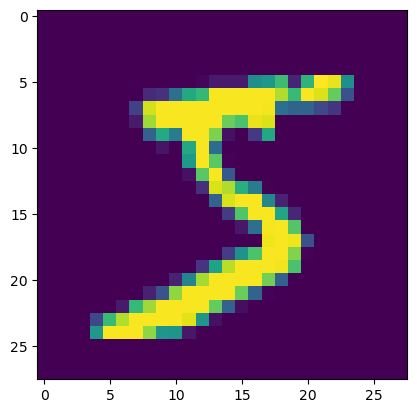

In [6]:
from matplotlib import pyplot as plt
plt.imshow(xtrain[0,:,:])

In [7]:
ytrain[0] # The output label for the image shown above

5

In [8]:
x_train=xtrain.reshape(60000,28*28) # reshaping images as one dimensional
x_test=xtest.reshape(10000,28*28)

In [9]:
x_train=x_train/255. # scaling the images
x_test=x_test/255.

In [10]:
y_train=tf.keras.utils.to_categorical(ytrain,num_classes=10) # Encoding the target levels
y_test=tf.keras.utils.to_categorical(ytest,num_classes=10) 

In [11]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [12]:
ytrain[0]

5

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers, optimizers

In [14]:
#Create the function to define a DNN model with dynamic iteration, learning_rate, 
#regularization penalty# neurons in the hidden layer for tuning
def train_and_test_model(itr,learning_rate,lamda):
    
    iterations=itr
    learning_rate=learning_rate
    hidden_nodes=256
    output_nodes=10
    
    model=Sequential()
    model.add(Dense(units=hidden_nodes,activation='relu',input_dim=784)) # input layer with 784 nodes as i have 28*28 pixels in the image, 
    # hidden layer with 256 nodes and output layer with 10 nodes as i have 10 classes
    model.add(Dense(units=hidden_nodes,activation='relu'))
    model.add(Dense(units=output_nodes,activation='softmax',kernel_regularizer=regularizers.l2(lamda)))
    
    sgd=optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy',optimizer=sgd,metrics=['accuracy'])
    
    # since batch size is 1000, the model will be updated after every 1000 samples,
    # soo there will be 60 epoch or updates as i have 60000 samples in the training data
    model.fit(x_train,y_train,epochs=iterations,batch_size=1000,verbose=0)
    [loss,score_train]=model.evaluate(x_train,y_train)
    [loss,score_test]=model.evaluate(x_test,y_test)
    
    return score_train,score_test  # returning both train and test scores

In [15]:
learning_rate=0.00001 # Choose very small value of learning rate
lamda=0
train_and_test_model(10,learning_rate,lamda) # Leading to vanishing gradiant problem
# loss is not changing in each iteration much and model accuracy is poor. 
#To understand it run with verbose =1 in the above function

d:\programFiles\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0742 - loss: 2.3497
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0760 - loss: 2.3467


(0.07415000349283218, 0.07599999755620956)

In [16]:
learning_rate=0.001 # Increasing the learning_rate to 0.001 improving the performance slightly
lamda=0 # no regularization
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5520 - loss: 1.9631
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5642 - loss: 1.9548


(0.5519999861717224, 0.5641999840736389)

In [17]:
learning_rate=0.1# Increasing the learning_rate to 0.1 improving the performance above 90 percent
lamda=0
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9421 - loss: 0.2026
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9400 - loss: 0.2020


(0.9421499967575073, 0.9399999976158142)

In [18]:
learning_rate=1.0 # learning rate of 1 giving very good results for this datset [It may not be same for all the data]
lamda=0
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9805 - loss: 0.0657
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9704 - loss: 0.0958


(0.9805499911308289, 0.9703999757766724)

In [19]:
learning_rate=50.0   # Increasing the lr to 50 leading to Exploding Gradient. Loss going out of control
lamda=0
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0992 - loss: 10.9281
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1009 - loss: 10.9762


(0.09915000200271606, 0.10090000182390213)

In [20]:
learning_rate=0.0000001  # Vanishing Gradient
lamda=0
train_and_test_model(10,learning_rate,lamda)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1085 - loss: 2.3402
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1073 - loss: 2.3449


(0.10846666991710663, 0.10729999840259552)

In [21]:
learning_rate=1.0
lamda=0.02 # Introduce small regularization, regularization will reduce overfitting, but bias error may slightly increase
train_and_test_model(10,learning_rate,lamda) # Less overfitting

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9542 - loss: 0.2057
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9494 - loss: 0.2146


(0.9542166590690613, 0.949400007724762)

In [22]:
learning_rate=1.0
lamda=1 
train_and_test_model(10,learning_rate,lamda) # Underfitting, penalty(lamda) of 1, reducing the performance greatly

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1125 - loss: 25.5777
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1135 - loss: 25.5775


(0.1124500036239624, 0.11349999904632568)

In [23]:
#Coarse tuning - Explore the model for wide span of learning rate and lamda(regularization penalty)
learning_rate=[0.0001,0.001,0.01,0.1,1.0,10.0,20.0,50.0]
lam=[0.0001,0.001,0.01,0.1,1,10,20,50]
for i,j in zip(learning_rate,lam):
    score=train_and_test_model(10,i,j)
    print('epocs:',10,'train_accuracy:',score[0],'test_accuracy:',score[1],'alpha:', i,'Regularization:',j)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1804 - loss: 2.2886
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1811 - loss: 2.2837
epocs: 10 train_accuracy: 0.18043333292007446 test_accuracy: 0.181099995970726 alpha: 0.0001 Regularization: 0.0001
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5270 - loss: 2.0172
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5263 - loss: 2.0125
epocs: 10 train_accuracy: 0.5270166397094727 test_accuracy: 0.5263000130653381 alpha: 0.001 Regularization: 0.001
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8712 - loss: 0.7169
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8761 - loss: 0.6938
epocs: 10 train_accuracy: 0.8712499737739563 test_accuracy: 0.8761000037193298 alpha: 0.01 Regularization: 0.01
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8972 - loss: 0.5209
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9005 - loss: 0.5052
epocs: 10 train_accuracy: 0.8971666693687439 test_

In [24]:
# till here

In [25]:
#Another random way of doing coarse tuning
import math
for k in range(1,10):
    learning_rate = math.pow(10, np.random.uniform(-7.0, 3.0))
    Lambda = math.pow(10, np.random.uniform(-7,-2))
    best_acc = train_and_test_model(10, learning_rate, Lambda)
    print('k:',k,'epocs:',100,'accuracy:',best_acc,'alpha:', learning_rate,'Regularization:',Lambda)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0993 - loss: 5935136386318336.0000
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1032 - loss: 5935034917715968.0000
k: 1 epocs: 100 accuracy: (0.09929999709129333, 0.10320000350475311) alpha: 103.77448289954704 Regularization: 2.154778166273467e-05
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0904 - loss: 2.3690
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0894 - loss: 2.3650
k: 2 epocs: 100 accuracy: (0.0903666689991951, 0.08940000087022781) alpha: 3.9697676885501425e-07 Regularization: 1.1866969562173592e-06
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8099 - loss: 1.0079
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8186 - loss: 0.9792
k: 3 epocs: 100 accuracy: (0.8098666667938232, 0.8185999989509583) alpha: 0.004770043146248851 Regularization: 0.0060549905400525145
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0732 - loss: 2.3299
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2m

In [26]:
import math
math.pow(10,np.random.uniform(-7.0, 3.0))

3.0625546479459835e-05

In [27]:
#Create the function to define a DNN model with dynamic learning_rate, regularization penalty
         # neurons in the hidden layer,activation function and weight intitialization for tuning
def tune_model(learning_rate,activation, lamda,initializer,num_unit):
    model = Sequential()
    model.add(Dense(num_unit, kernel_initializer=initializer,activation=activation, input_dim=784))
    #model.add(Dropout(dropout_rate))
    model.add(Dense(num_unit, kernel_initializer=initializer,activation=activation))
    #model.add(Dropout(dropout_rate)) 
    model.add(Dense(10, activation='softmax',kernel_regularizer=regularizers.l2(lamda)))
    sgd = optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy',optimizer=sgd,metrics=['accuracy'])
    return model

In [28]:
#he_normal 
#std = sqrt(2/fan_in)
#fan_in= number of neurons in the hiddenlayer

In [29]:
#Define hyper parameters values
batch_size = [20, 50, 100][:1]
epochs = [1, 20, 50][:1]
initializer = ['lecun_uniform', 'normal', 'he_normal', 'he_uniform'][:1]
learning_rate = [0.1, 0.001, 0.02][:1]
lamda = [0.001, 0.005, 0.01][:1]
num_unit = [256, 128][:1]
activation = ['relu', 'tanh', 'sigmoid', 'hard_sigmoid', 'linear'][:1]

In [30]:
#create dictionary with hyper parameters
parameters = dict(batch_size = batch_size,
                  epochs = epochs,
                  learning_rate=learning_rate,
                  lamda = lamda,
                  num_unit = num_unit,
                  initializer = initializer,
                  activation = activation)

In [31]:
parameters

{'batch_size': [20],
 'epochs': [1],
 'learning_rate': [0.1],
 'lamda': [0.001],
 'num_unit': [256],
 'initializer': ['lecun_uniform'],
 'activation': ['relu']}

In [32]:
# Make this keras model compatible to sklearn to apply gridsearchCV
#model =tf.keras.wrappers.scikit_learn.KerasClassifier(build_fn=tune_model, verbose=0)
from scikeras.wrappers import KerasClassifier
model = KerasClassifier(model = tune_model, verbose=0, activation='relu',initializer='lecun_uniform',
                       lamda=0.001,learning_rate=0.1,num_unit=256)

In [33]:
from sklearn.model_selection import GridSearchCV
models = GridSearchCV(estimator = model, param_grid=parameters, n_jobs=1)

In [34]:
best_model = models.fit(x_train, y_train)
print('Best model :',best_model.best_params_)

d:\programFiles\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\programFiles\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\programFiles\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\programFiles\Lib\si

Best model : {'activation': 'relu', 'batch_size': 20, 'epochs': 1, 'initializer': 'lecun_uniform', 'lamda': 0.001, 'learning_rate': 0.1, 'num_unit': 256}


In [35]:
import pandas as pd
pd.DataFrame(best_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_batch_size,param_epochs,param_initializer,param_lamda,param_learning_rate,param_num_unit,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,7.083103,0.118495,1.308077,0.107354,relu,20,1,lecun_uniform,0.001,0.1,256,"{'activation': 'relu', 'batch_size': 20, 'epoc...",0.963167,0.9505,0.944583,0.954333,0.962583,0.955033,0.007119,1


In [36]:
# Run for all the combinations and take the best results interms of both bias and variance error